In [73]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from eval_fluent_deeponet import *
from fluent_deeponet import DeepONet, build_fluent_deeponet_dataset, predict_deeponet_full_grid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

LATENT_DIM = 128
BRANCH_POINT_HIDDEN_DIM = 128
BRANCH_POINT_DEPTH = 3
BRANCH_GLOBAL_HIDDEN_DIM = 128
BRANCH_GLOBAL_DEPTH = 3
TRUNK_HIDDEN_DIM = 128
TRUNK_DEPTH = 4
AGGREGATION = "mean"

In [44]:
checkpoint_dir = Path("checkpoints")
checkpoint_path = checkpoint_dir / f"deeponet_rect_ar10_30_RngInt.pt"
ckpt = torch.load(checkpoint_path, map_location=DEVICE)

best_model = DeepONet(**ckpt["model_config"]).to(DEVICE)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()


branch_normalizer_predict = FeatureNormalizer.from_state_dict(
    ckpt["branch_normalizer"]
).to(DEVICE)

y_normalizer_predict = FeatureNormalizer.from_state_dict(
    ckpt["y_normalizer"]
).to(DEVICE)

/tmp/ipykernel_3117815/3191475739.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=DEVICE)


In [78]:
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/runs_2d/rect_ar")

ARS_TEST = [5]
AR_TEST = ARS_TEST[0]
TEST_SUBDOMAINS = 2
QUERY_BATCH_SIZE_TEST = 32768

nx, ny = 256, 256
include_corner_dupes = True

case_files_test = {
    AR: {
        "mesh": ROOT_DIR / f"rect_ar{AR:02d}_1e-1mps_2c/rect_ar{AR:02d}.msh.h5",
        "dat": ROOT_DIR / f"rect_ar{AR:02d}_1e-1mps_2c/case2d.dat.h5",
    } for AR in ARS_TEST
}

test_data = build_fluent_deeponet_dataset(
    case_files=case_files_test,
    ars=ARS_TEST,
    nx=nx,
    ny=ny,
    n_subdomains=TEST_SUBDOMAINS,
    include_corner_dupes=include_corner_dupes,
    keep_cases=False,
)

output_channel_names = list(test_data["output_channel_names"])

branch_test = test_data["branch_inputs"].astype(np.float32)
query_coords_test = test_data["query_coords"].astype(np.float32)
Y_test = test_data["outputs"].astype(np.float32)

if branch_test.shape[0] != Y_test.shape[0]:
    if branch_test.shape[0] == 2 * Y_test.shape[0]:
        print("Detected duplicated AR=50 branch rows; keeping every other branch row.")
        branch_test = branch_test[::2].copy()
    else:
        raise ValueError(
            f"branch_test and Y_test have incompatible sample counts: "
            f"{branch_test.shape[0]} vs {Y_test.shape[0]}"
        )

ar_test = np.asarray(test_data["aspect_ratio"]).astype(int)
subdomain_test = np.asarray(test_data["subdomain_id"]).astype(int)

print("branch_test:", branch_test.shape)
print("query_coords_test:", query_coords_test.shape)
print("Y_test:", Y_test.shape)
print("ARs in test set:", sorted(set(ar_test.tolist())))
print("Subdomain IDs in test set:", sorted(set(subdomain_test.tolist())))

pred_test_list = []
truth_test_list = []

for i in range(branch_test.shape[0]):
    pred_flat = predict_deeponet_full_grid(
        model=best_model,
        branch=branch_test[i],
        query_coords=query_coords_test,
        device=DEVICE,
        branch_normalizer=branch_normalizer_predict,
        y_normalizer=y_normalizer_predict,
        query_batch_size=QUERY_BATCH_SIZE_TEST,
    )
    pred_test_list.append(pred_flat.reshape(nx, ny, len(output_channel_names)).numpy())
    truth_test_list.append(Y_test[i])

pred_test = np.stack(pred_test_list, axis=0)
truth_test = np.stack(truth_test_list, axis=0)

# Relative L2 metrics.
num = np.linalg.norm((pred_test - truth_test).reshape(pred_test.shape[0], -1), axis=1)
den = np.linalg.norm(truth_test.reshape(truth_test.shape[0], -1), axis=1) + 1.0e-12
sample_rel_l2 = num / den
overall_rel_l2 = float(np.mean(sample_rel_l2))

per_field_rel_l2 = {}
for fi, fname in enumerate(output_channel_names):
    num_f = np.linalg.norm((pred_test[..., fi] - truth_test[..., fi]).reshape(pred_test.shape[0], -1), axis=1)
    den_f = np.linalg.norm(truth_test[..., fi].reshape(truth_test.shape[0], -1), axis=1) + 1.0e-12
    per_field_rel_l2[fname] = float(np.mean(num_f / den_f))

print(f"AR={AR_TEST} overall relative L2: {overall_rel_l2:.6e}")
for fname in output_channel_names:
    print(f"AR={AR_TEST} {fname} relative L2: {per_field_rel_l2[fname]:.6e}")

pred_path_test = f"results/test_predictions_deeponet_ar{AR_TEST}_sub{TEST_SUBDOMAINS}_5000e_RngInt.npz"
np.savez(
    pred_path_test,
    pred=pred_test,
    truth=truth_test,
    ar=ar_test,
    subdomain_id=subdomain_test,
    output_channel_names=np.array(output_channel_names, dtype=object),
    sample_rel_l2=sample_rel_l2,
)
print("Saved:", pred_path_test)


Processing AR=5 realization=0


Interface locations: [0.0, 375.0, 750.0]
branch_test: (2, 1024, 9)
query_coords_test: (65536, 2)
Y_test: (2, 256, 256, 4)
ARs in test set: [5]
Subdomain IDs in test set: [0, 1]
AR=5 overall relative L2: 3.005187e-05
AR=5 pressure relative L2: 1.622349e-02
AR=5 temperature relative L2: 2.994646e-05
AR=5 u relative L2: 6.640255e-03
AR=5 v relative L2: 4.715688e-02
Saved: results/test_predictions_deeponet_ar5_sub2_5000e_RngInt.npz


Plotting AR=5 sample index: 0 subdomain: 0
Stitched subdomains: [0, 1]


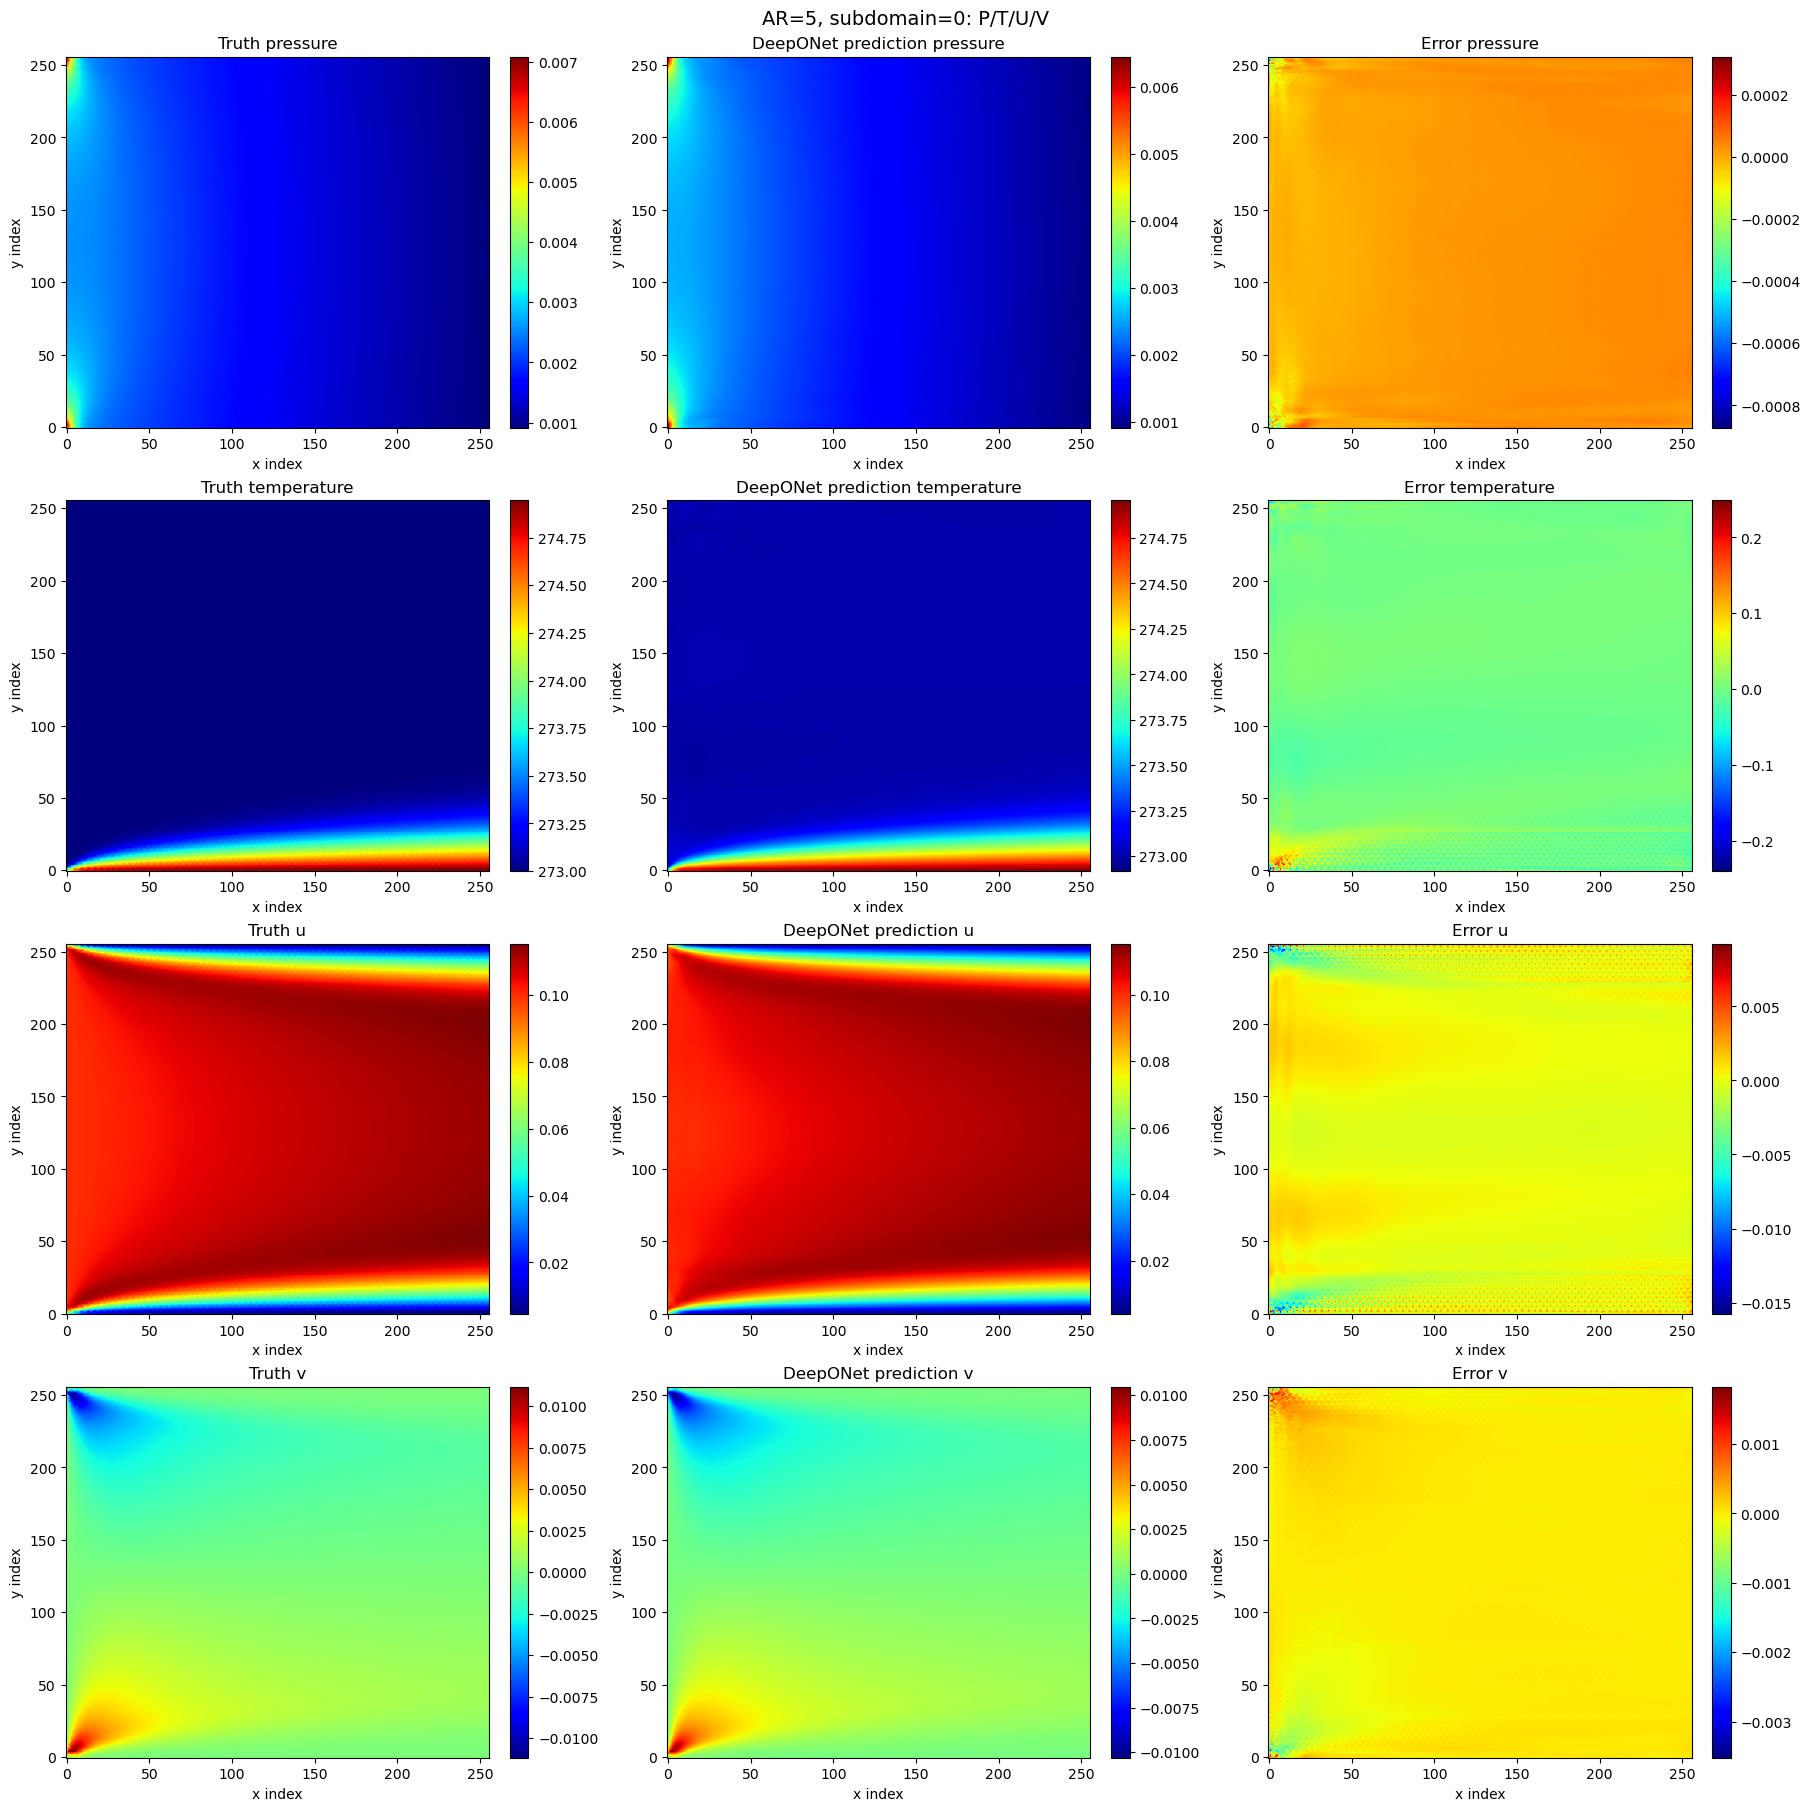

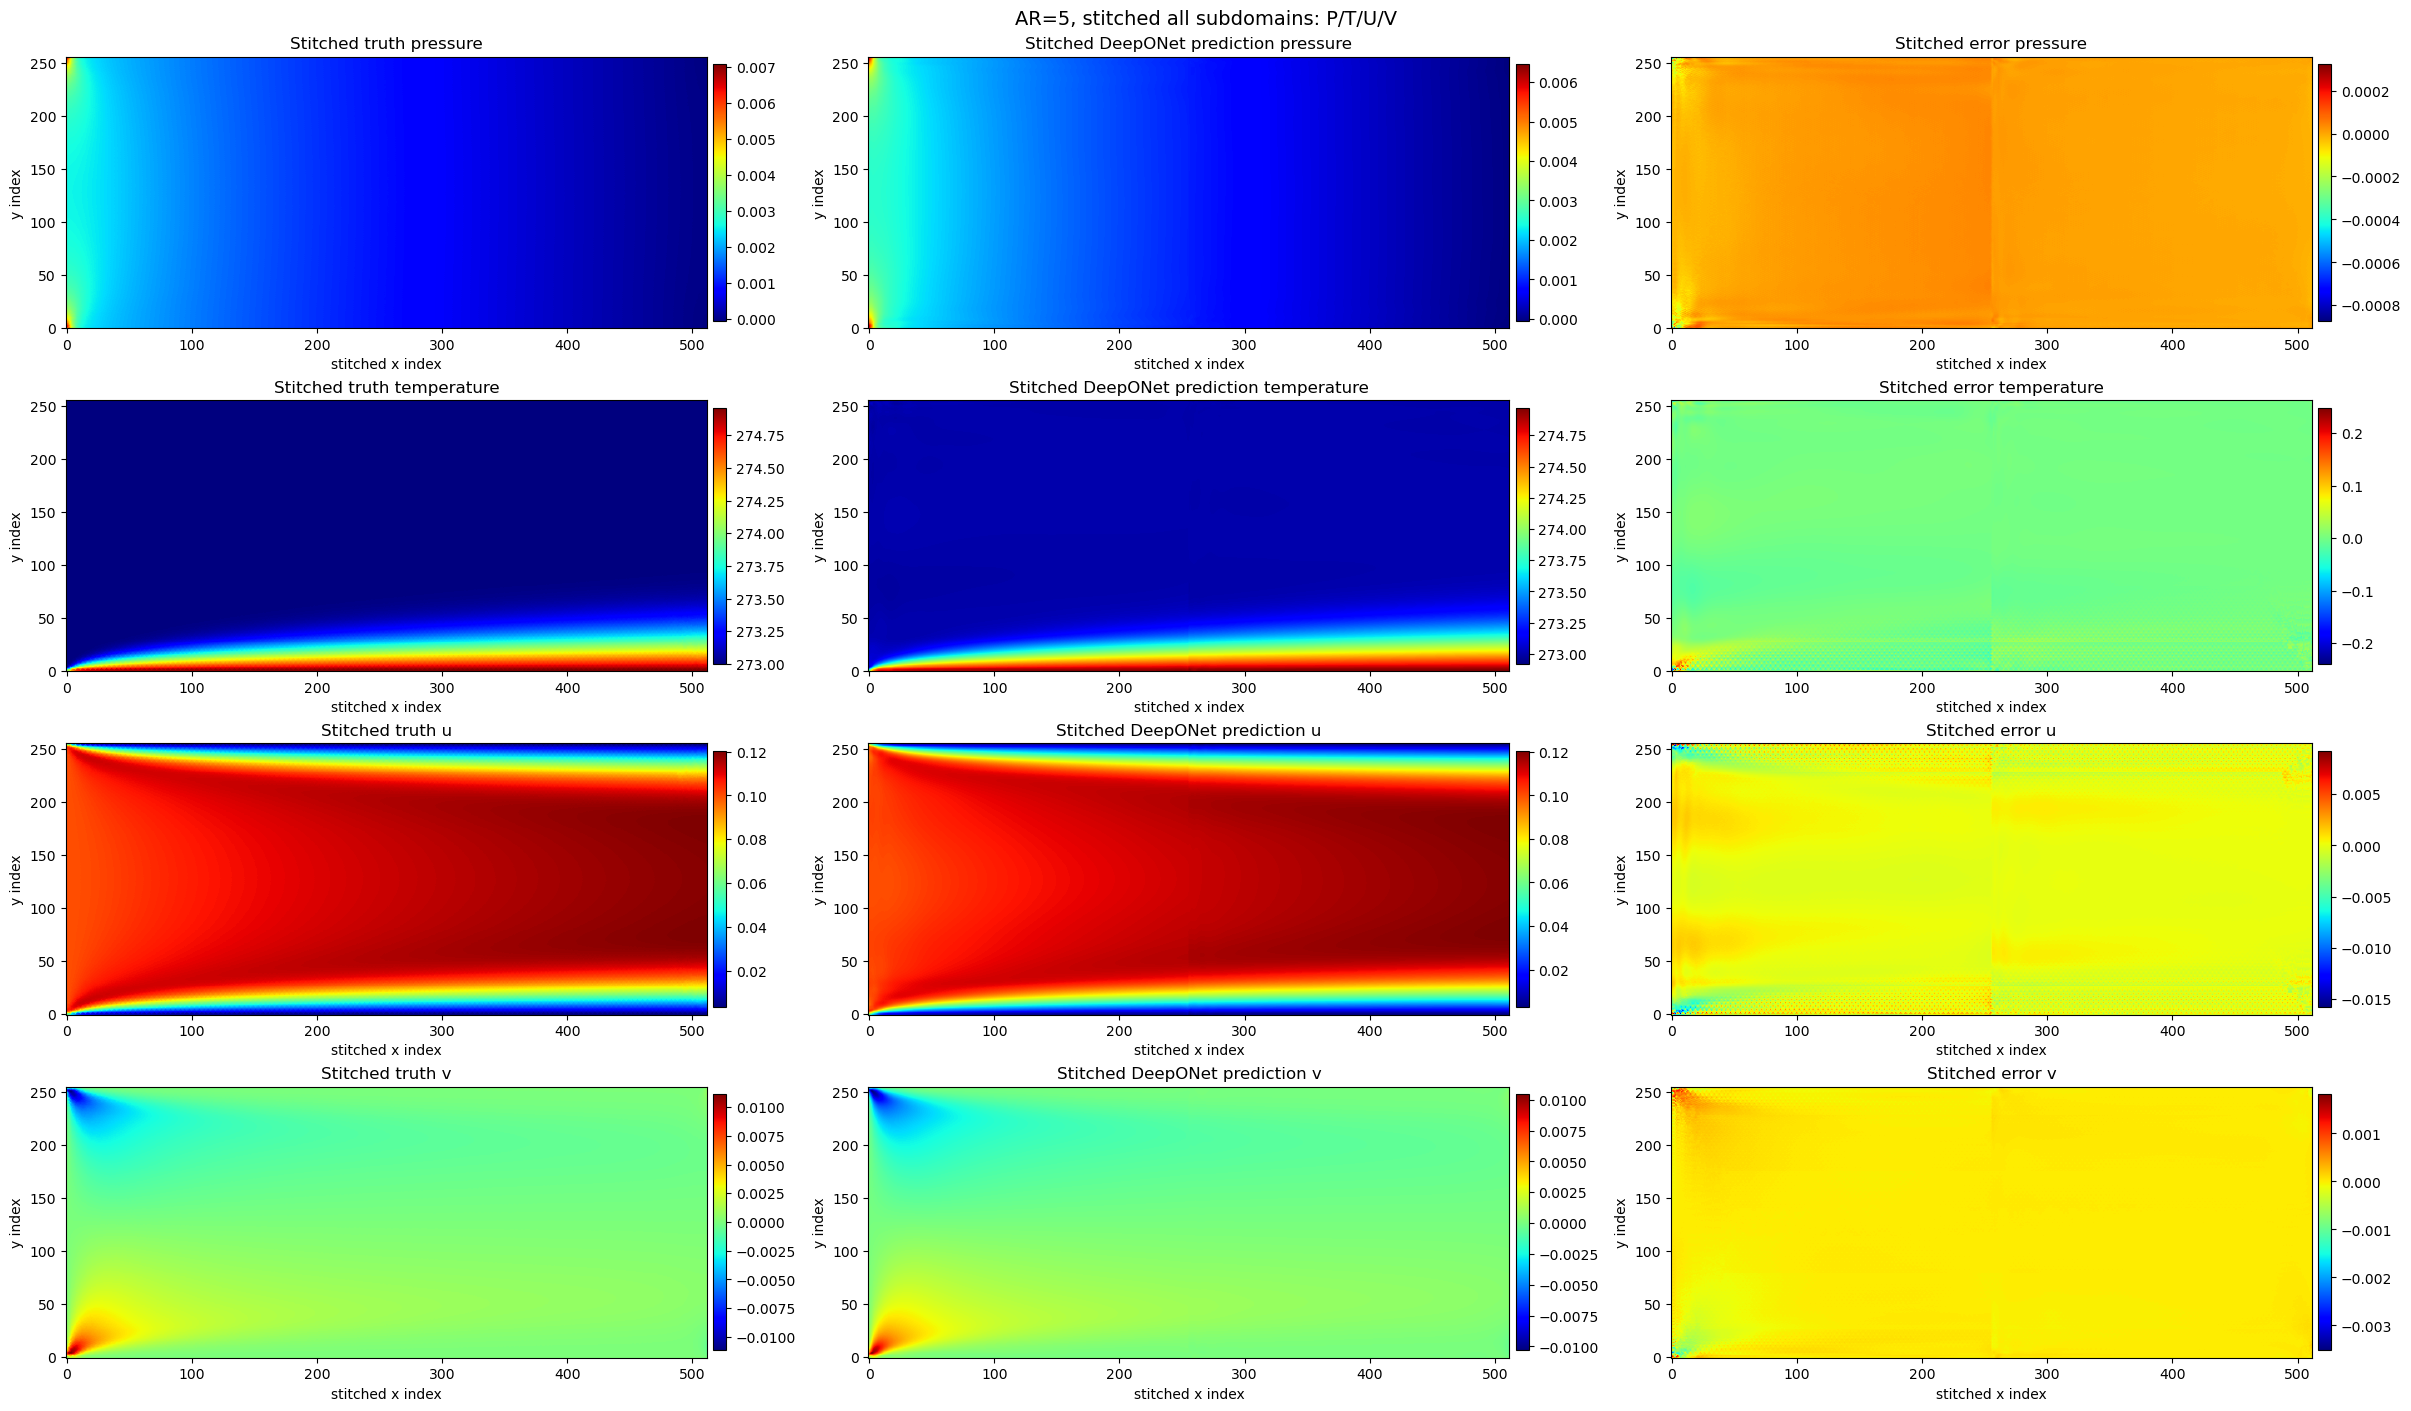

In [81]:
# --- Plot P/T/U/V on one AR=50 subdomain ---
subdomain_to_plot = 0
sample_candidates = np.where(subdomain_test == subdomain_to_plot)[0]
if len(sample_candidates) == 0:
    raise ValueError(f"Subdomain {subdomain_to_plot} not found in AR={AR_TEST} test set")

sample_idx = int(sample_candidates[0])
print(f"Plotting AR={AR_TEST} sample index:", sample_idx, "subdomain:", subdomain_test[sample_idx])

# Stitched full geometry sorted by subdomain id.
sort_idx = np.argsort(subdomain_test)
subdomain_sorted = subdomain_test[sort_idx]
pred_stitched = np.concatenate([pred_test[i] for i in sort_idx], axis=0)
truth_stitched = np.concatenate([truth_test[i] for i in sort_idx], axis=0)
err_stitched = pred_stitched - truth_stitched
print("Stitched subdomains:", subdomain_sorted.tolist())

# Figure 1: single subdomain.
fig1, axes1 = plt.subplots(len(output_channel_names), 3, figsize=(18, 18), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_test[sample_idx, :, :, fi]
    pred_f = pred_test[sample_idx, :, :, fi]
    err_f = pred_f - truth_f

    im0 = axes1[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 0].set_title(f"Truth {fname}")
    axes1[fi, 0].set_xlabel("x index")
    axes1[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes1[fi, 0], fraction=0.046, pad=0.04)

    im1 = axes1[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 1].set_title(f"DeepONet prediction {fname}")
    axes1[fi, 1].set_xlabel("x index")
    axes1[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes1[fi, 1], fraction=0.046, pad=0.04)

    im2 = axes1[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes1[fi, 2].set_title(f"Error {fname}")
    axes1[fi, 2].set_xlabel("x index")
    axes1[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes1[fi, 2], fraction=0.046, pad=0.04)

fig1.suptitle(f"AR={AR_TEST}, subdomain={subdomain_to_plot}: P/T/U/V", fontsize=14)
plt.show()

# Figure 2: stitched full geometry.
fig2, axes2 = plt.subplots(len(output_channel_names), 3, figsize=(24, 14), constrained_layout=True)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_stitched[:, :, fi]
    pred_f = pred_stitched[:, :, fi]
    err_f = err_stitched[:, :, fi]

    im0 = axes2[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 0].set_title(f"Stitched truth {fname}")
    axes2[fi, 0].set_xlabel("stitched x index")
    axes2[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes2[fi, 0], fraction=0.02, pad=0.01)

    im1 = axes2[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 1].set_title(f"Stitched DeepONet prediction {fname}")
    axes2[fi, 1].set_xlabel("stitched x index")
    axes2[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes2[fi, 1], fraction=0.02, pad=0.01)

    im2 = axes2[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes2[fi, 2].set_title(f"Stitched error {fname}")
    axes2[fi, 2].set_xlabel("stitched x index")
    axes2[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes2[fi, 2], fraction=0.02, pad=0.01)

fig2.suptitle(f"AR={AR_TEST}, stitched all subdomains: P/T/U/V", fontsize=14)
plt.show()


In [82]:
truth_test[0].shape
left_truth = truth_test[0]
right_truth = truth_test[1]

left_pred = pred_test[0]
right_pred = pred_test[1]

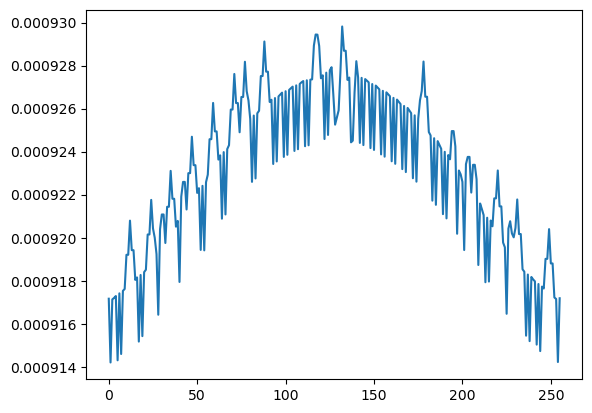

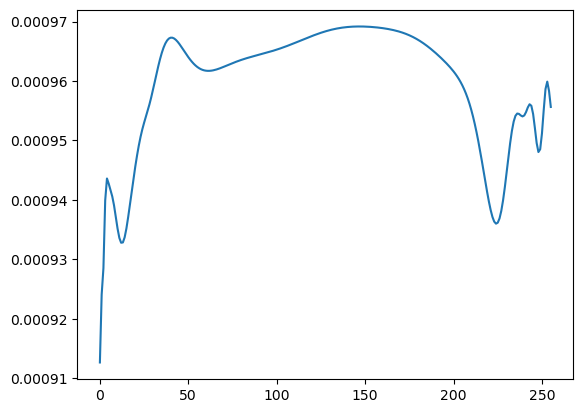

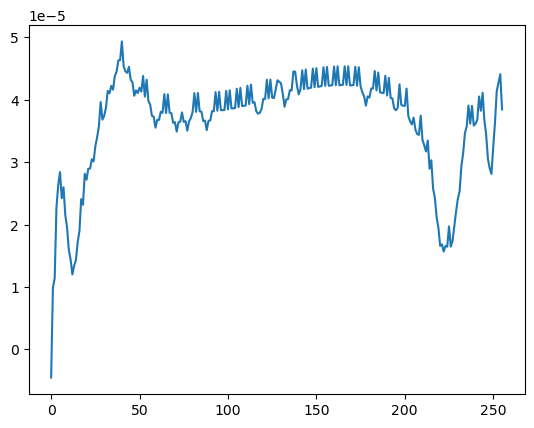

In [83]:
channel_idx = 0

left_int_truth = left_truth[-1, :, channel_idx]
plt.plot(left_int_truth)
plt.show()

left_int_pred = left_pred[-1, :, channel_idx]
plt.plot(left_int_pred)
plt.show()

left_int_err = left_int_pred - left_int_truth
plt.plot(left_int_err)
plt.show()

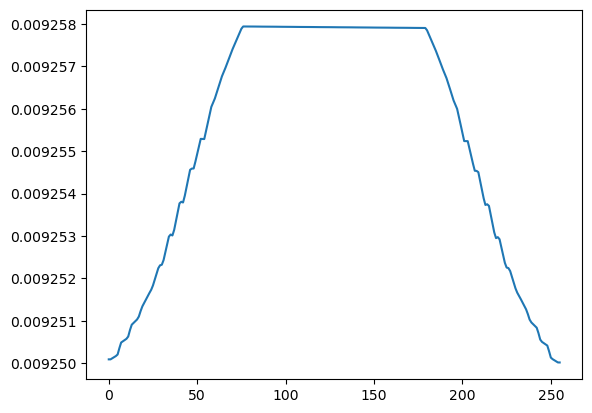

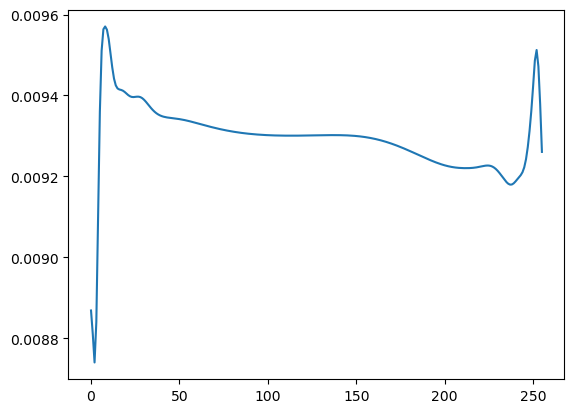

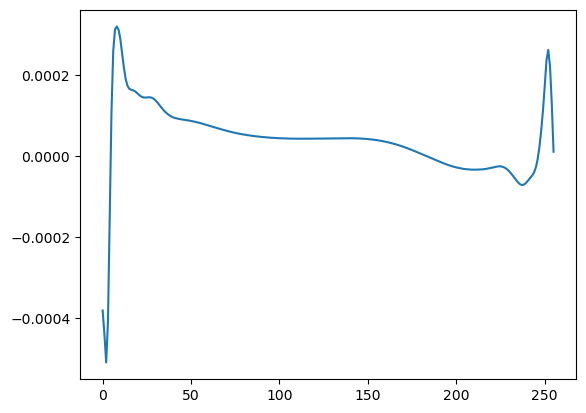

In [69]:
right_int_truth = right_truth[0, :, channel_idx]
plt.plot(right_int_truth)
plt.show()

right_int_pred = right_pred[0, :, channel_idx]
plt.plot(right_int_pred)
plt.show()

right_int_err = right_int_pred - right_int_truth
plt.plot(right_int_err)
plt.show()

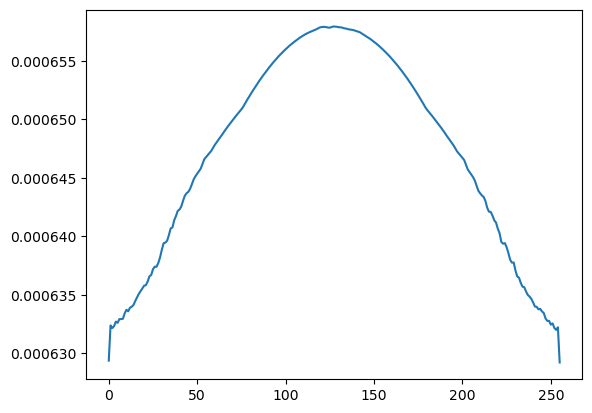

In [50]:
truth_err = left_int_truth - right_int_truth
plt.plot(truth_err)
plt.show()

In [51]:
idx_test = select_ar_subdomains(
    test_data,
    ar=AR_TEST,
)

config = InterfaceIterationConfig(
    max_iter=500,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1,
    random_seed=0,
    init_mode="pointwise_random",
    init_std_scale=1.0,
    init_value=0.0,
    init_noise_std=0,
    query_batch_size=32768,
    sample_batch_size=4,
    preserve_wall_corners=False,
    verbose=True,
)

result = iterative_unknown_interface_inference(
    model=best_model,
    branch_inputs_for_ar=test_data["branch_inputs"][idx_test],
    query_coords=test_data["query_coords"],
    nx=test_data["nx"],
    ny=test_data["ny"],
    branch_channel_names=test_data["branch_channel_names"],
    device=DEVICE,
    branch_normalizer=branch_normalizer_predict,
    y_normalizer=y_normalizer_predict,
    config=config,
)

# result = optimize_interfaces_flux_matching(
#     model=best_model,
#     branch_inputs_for_ar=test_data["branch_inputs"][idx_test],
#     query_coords=test_data["query_coords"],
#     nx=test_data["nx"],
#     ny=test_data["ny"],
#     branch_channel_names=test_data["branch_channel_names"],
#     device=DEVICE,
#     branch_normalizer=branch_normalizer,
#     y_normalizer=y_normalizer,
#     alpha=1.0,
#     beta=0.1,
#     max_iter=200,
#     lr=0.05
# )

iter=0000 | interface MSE max=1.362750e+05, mean=1.297861e+05 | converged=0/19
iter=0001 | interface MSE max=1.813457e+05, mean=1.672507e+05 | converged=0/19
iter=0002 | interface MSE max=3.147175e+05, mean=2.812627e+05 | converged=0/19
iter=0003 | interface MSE max=9.088964e+05, mean=7.823972e+05 | converged=0/19
iter=0004 | interface MSE max=3.240039e+06, mean=2.731401e+06 | converged=0/19
iter=0005 | interface MSE max=1.122241e+07, mean=9.276179e+06 | converged=0/19
iter=0006 | interface MSE max=3.727620e+07, mean=3.027846e+07 | converged=0/19
iter=0007 | interface MSE max=1.233563e+08, mean=9.849666e+07 | converged=0/19
iter=0008 | interface MSE max=4.100568e+08, mean=3.219527e+08 | converged=0/19
iter=0009 | interface MSE max=1.366756e+09, mean=1.055947e+09 | converged=0/19
iter=0010 | interface MSE max=4.559068e+09, mean=3.465951e+09 | converged=0/19
iter=0011 | interface MSE max=1.520215e+10, mean=1.137444e+10 | converged=0/19
iter=0012 | interface MSE max=5.066816e+10, mean=3.7

/home/hantianl/.miniconda3/envs/pinn/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/hantianl/Documents/PIDIF/FNO/eval_fluent_deeponet.py:613: RuntimeWarning: overflow encountered in square
  mse_by_channel = np.mean(diff ** 2, axis=1)
/home/hantianl/Documents/PIDIF/FNO/eval_fluent_deeponet.py:614: RuntimeWarning: overflow encountered in square
  mse_total = np.mean(diff ** 2, axis=(1, 2))


iter=0065 | interface MSE max=inf, mean=inf | converged=0/19
iter=0066 | interface MSE max=inf, mean=inf | converged=0/19
iter=0067 | interface MSE max=inf, mean=inf | converged=0/19
iter=0068 | interface MSE max=inf, mean=inf | converged=0/19
iter=0069 | interface MSE max=inf, mean=inf | converged=0/19
iter=0070 | interface MSE max=inf, mean=inf | converged=0/19
iter=0071 | interface MSE max=inf, mean=inf | converged=0/19
iter=0072 | interface MSE max=inf, mean=inf | converged=0/19
iter=0073 | interface MSE max=inf, mean=inf | converged=0/19
iter=0074 | interface MSE max=inf, mean=inf | converged=0/19
iter=0075 | interface MSE max=inf, mean=inf | converged=0/19
iter=0076 | interface MSE max=inf, mean=inf | converged=0/19
iter=0077 | interface MSE max=inf, mean=inf | converged=0/19
iter=0078 | interface MSE max=inf, mean=inf | converged=0/19
iter=0079 | interface MSE max=inf, mean=inf | converged=0/19
iter=0080 | interface MSE max=inf, mean=inf | converged=0/19
iter=0081 | interface MS

In [52]:
pred_subdomains = np.asarray(result["pred_grid"], dtype=np.float32)
pred_stitched = np.asarray(result["pred_stitched"], dtype=np.float32)
print("pred_subdomains:", pred_subdomains.shape)
print("pred_stitched:", pred_stitched.shape)

truth_subdomains = np.asarray(test_data["outputs"][idx_test], dtype=np.float32)
truth_stitched = stitch_subdomain_grids(truth_subdomains)
output_channel_names = list(test_data["output_channel_names"])
print("truth_subdomains:", truth_subdomains.shape)
print("truth_stitched:", truth_stitched.shape)

pred_subdomains: (20, 256, 256, 4)
pred_stitched: (5101, 256, 4)
truth_subdomains: (20, 256, 256, 4)
truth_stitched: (5101, 256, 4)


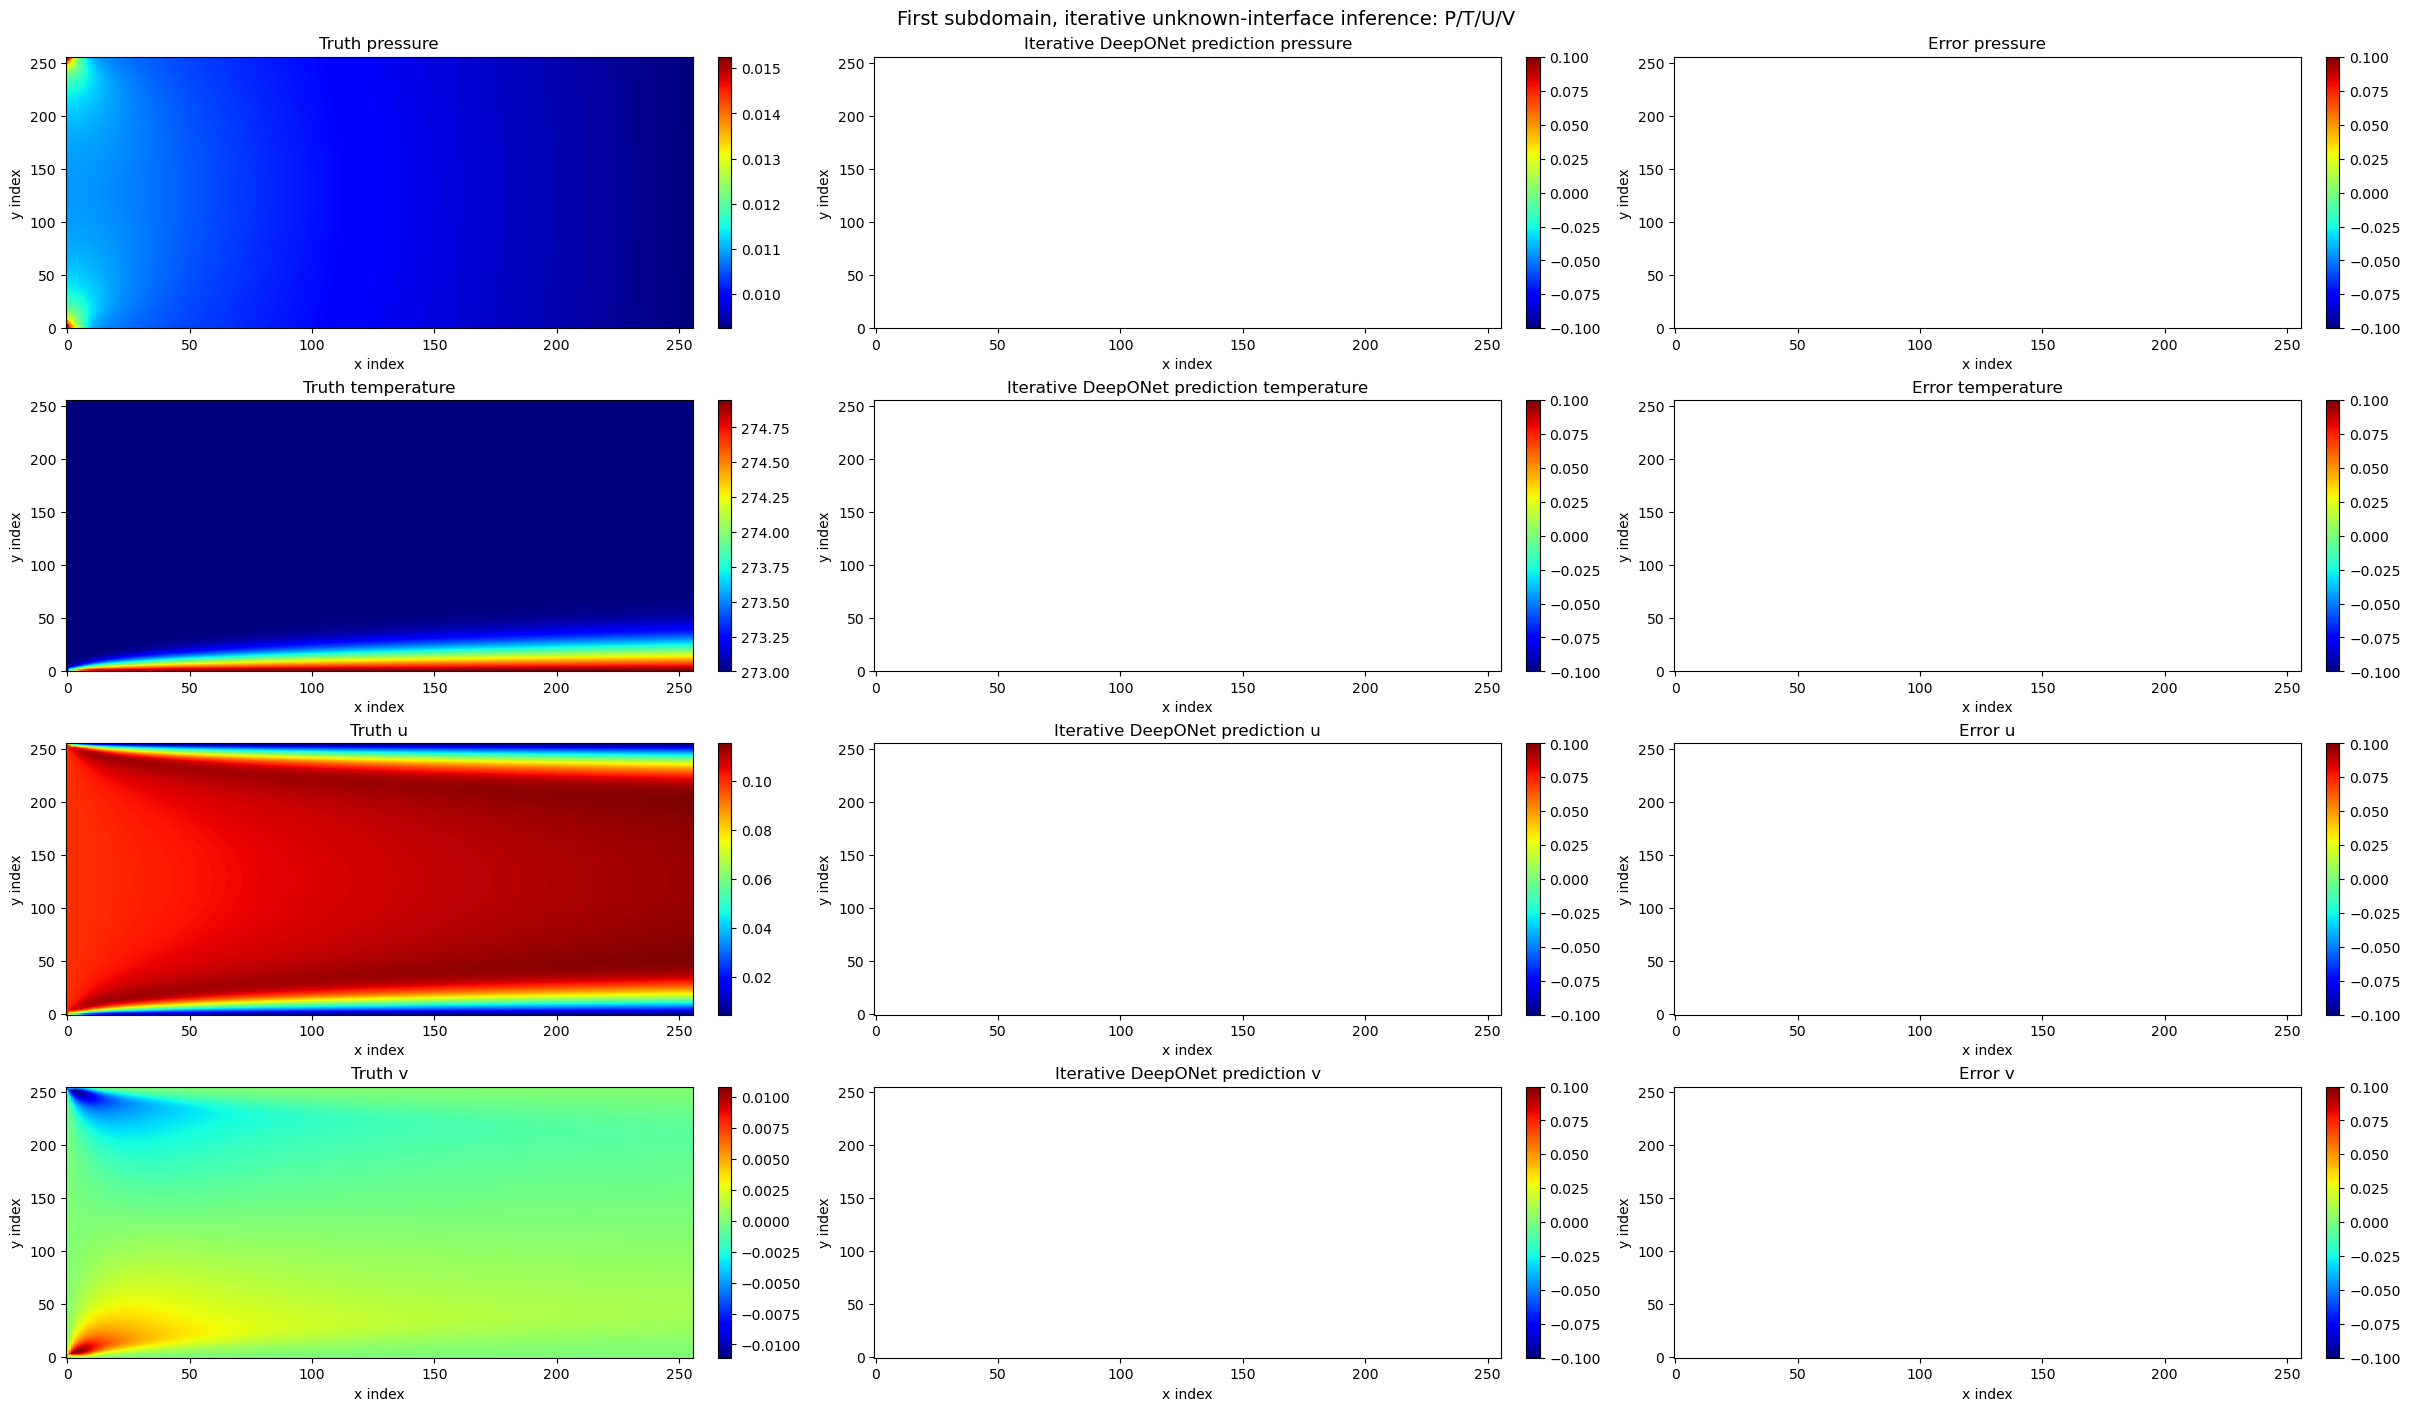

In [53]:
subdomain_to_plot = 0

pred_one = pred_subdomains[subdomain_to_plot]
truth_one = truth_subdomains[subdomain_to_plot]
err_one = pred_one - truth_one

fig, axes = plt.subplots(
    len(output_channel_names),
    3,
    figsize=(24, 14),
    constrained_layout=True,
)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_one[:, :, fi]
    pred_f = pred_one[:, :, fi]
    err_f = err_one[:, :, fi]

    im0 = axes[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 0].set_title(f"Truth {fname}")
    axes[fi, 0].set_xlabel("x index")
    axes[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes[fi, 0], fraction=0.046, pad=0.04)

    im1 = axes[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 1].set_title(f"Iterative DeepONet prediction {fname}")
    axes[fi, 1].set_xlabel("x index")
    axes[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes[fi, 1], fraction=0.046, pad=0.04)

    im2 = axes[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 2].set_title(f"Error {fname}")
    axes[fi, 2].set_xlabel("x index")
    axes[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes[fi, 2], fraction=0.046, pad=0.04)

fig.suptitle(
    f"First subdomain, iterative unknown-interface inference: P/T/U/V",
    fontsize=14,
)
plt.show()

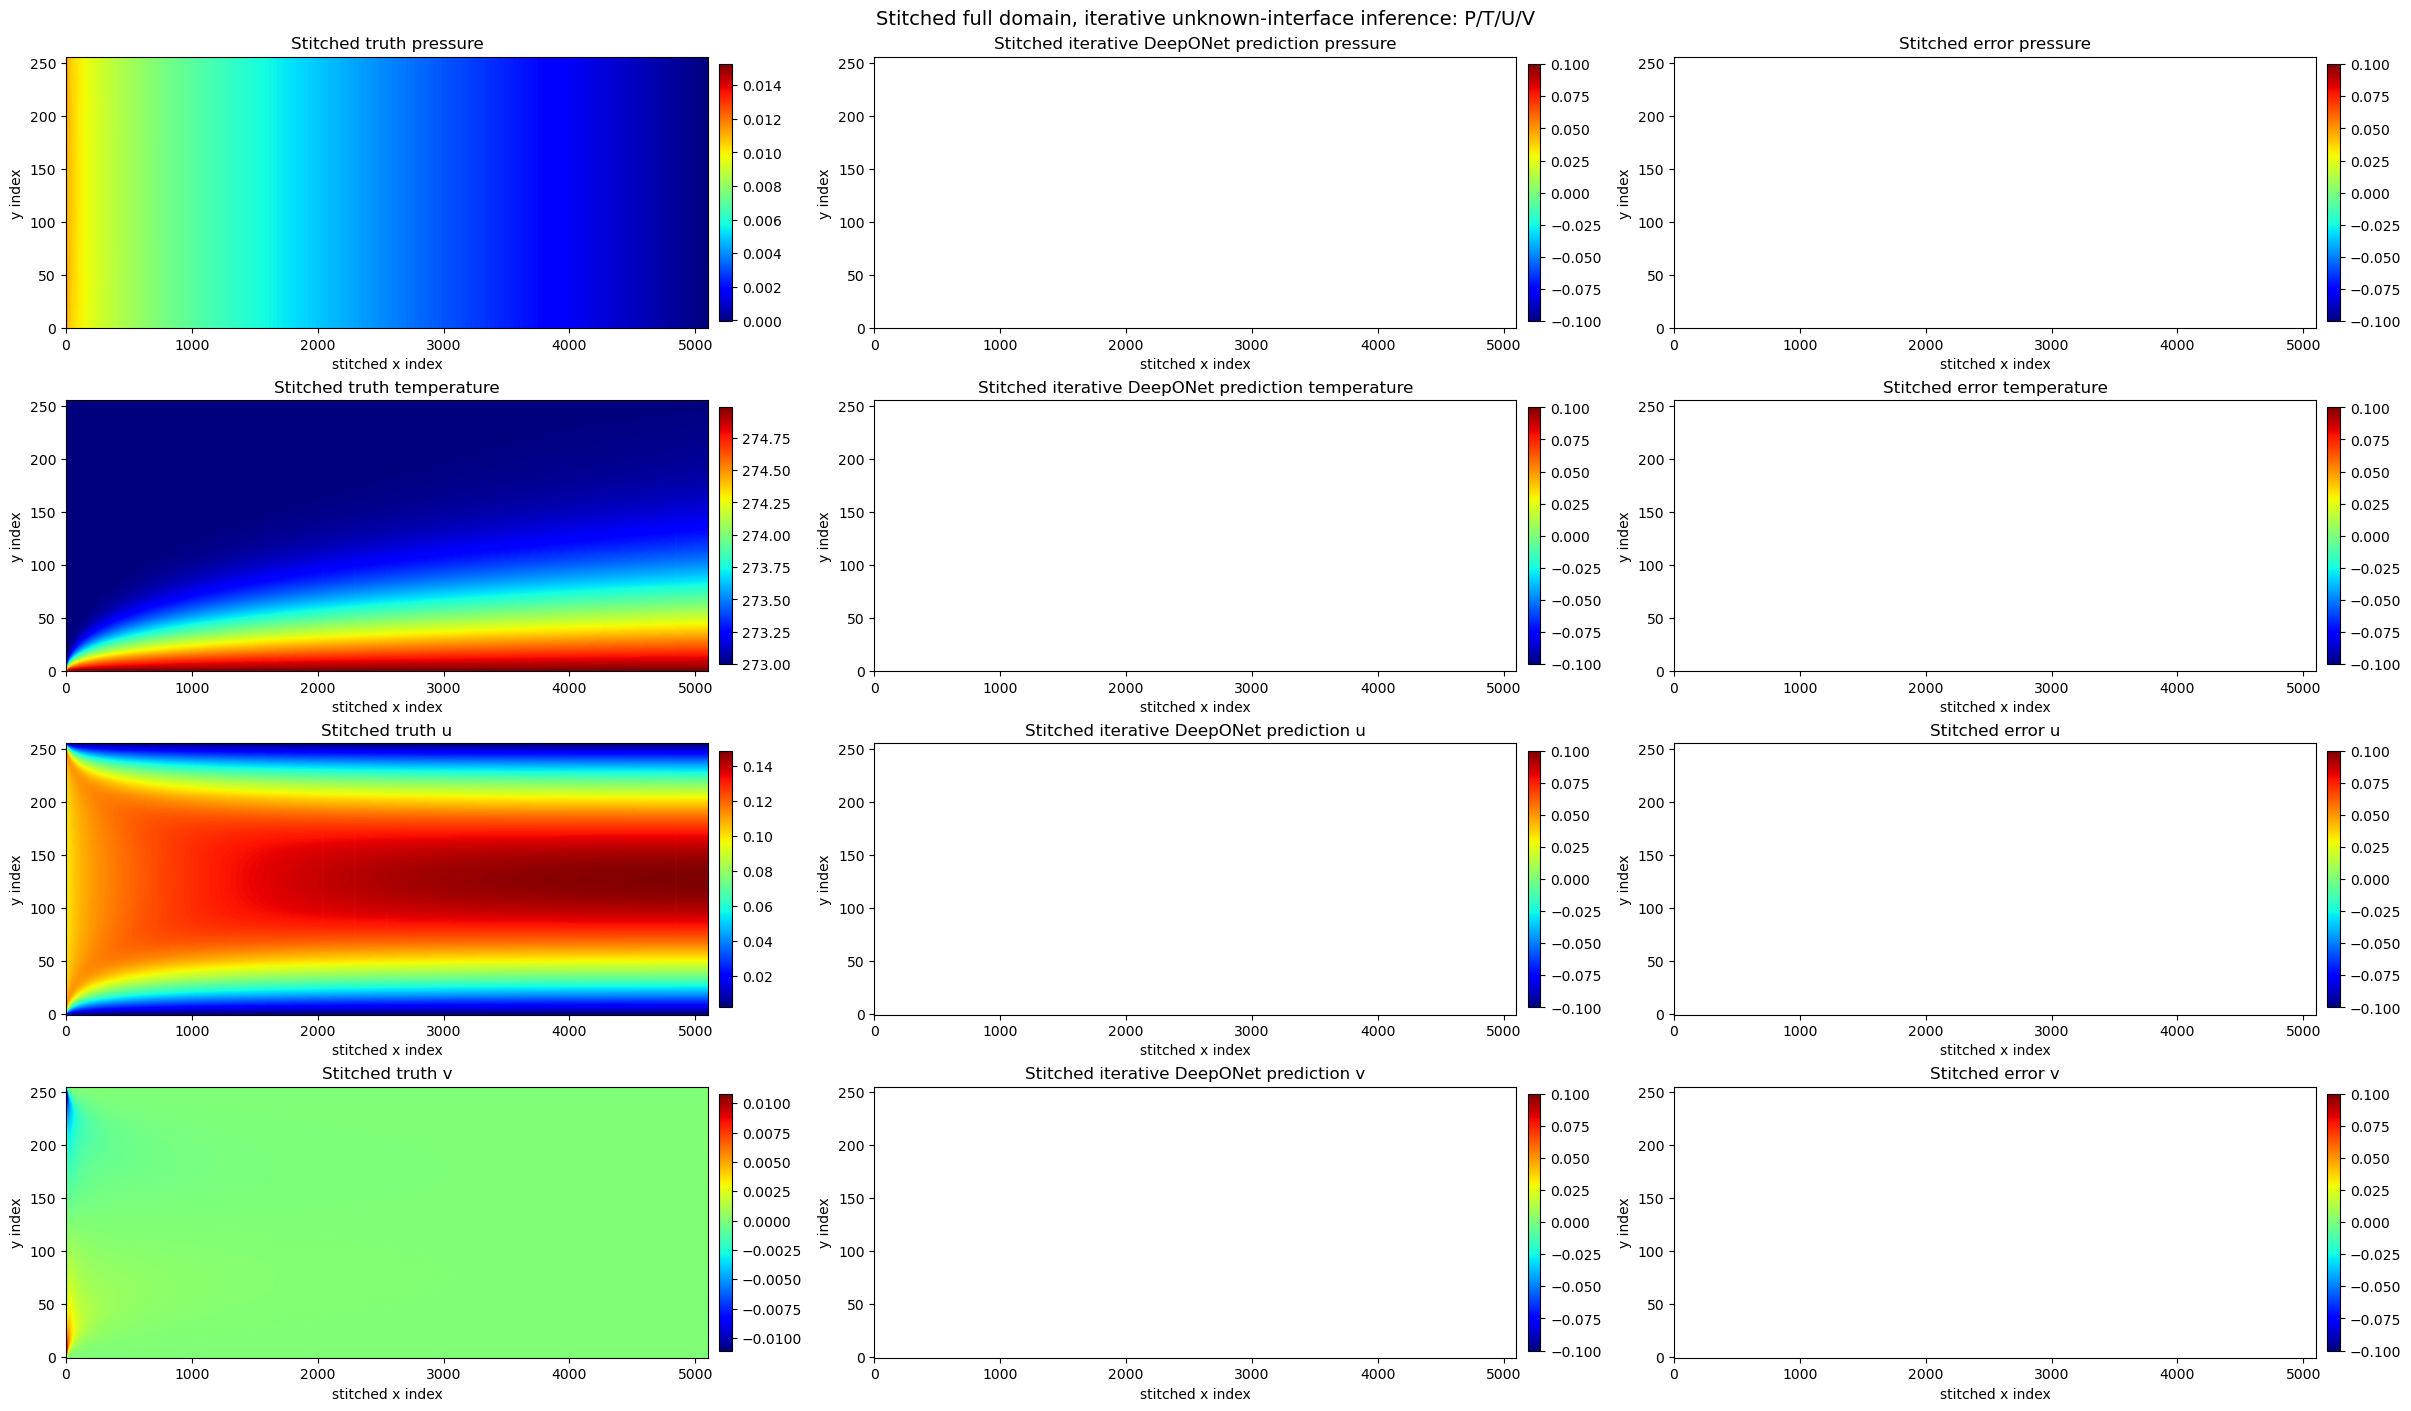

In [54]:
err_stitched = pred_stitched - truth_stitched

fig, axes = plt.subplots(
    len(output_channel_names),
    3,
    figsize=(24, 14),
    constrained_layout=True,
)

for fi, fname in enumerate(output_channel_names):
    truth_f = truth_stitched[:, :, fi]
    pred_f = pred_stitched[:, :, fi]
    err_f = err_stitched[:, :, fi]

    im0 = axes[fi, 0].imshow(truth_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 0].set_title(f"Stitched truth {fname}")
    axes[fi, 0].set_xlabel("stitched x index")
    axes[fi, 0].set_ylabel("y index")
    plt.colorbar(im0, ax=axes[fi, 0], fraction=0.02, pad=0.01)

    im1 = axes[fi, 1].imshow(pred_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 1].set_title(f"Stitched iterative DeepONet prediction {fname}")
    axes[fi, 1].set_xlabel("stitched x index")
    axes[fi, 1].set_ylabel("y index")
    plt.colorbar(im1, ax=axes[fi, 1], fraction=0.02, pad=0.01)

    im2 = axes[fi, 2].imshow(err_f.T, origin="lower", aspect="auto", cmap="jet")
    axes[fi, 2].set_title(f"Stitched error {fname}")
    axes[fi, 2].set_xlabel("stitched x index")
    axes[fi, 2].set_ylabel("y index")
    plt.colorbar(im2, ax=axes[fi, 2], fraction=0.02, pad=0.01)

fig.suptitle(
    "Stitched full domain, iterative unknown-interface inference: P/T/U/V",
    fontsize=14,
)
plt.show()